# Ergodicity

* Time averaged: one trial averaged across all time points (average along time).
* Ensemble averaged: average across trials at one same time point (average across trials).
* Global average: all trials over all time points.

## Ergodicity: ensemble averages, time averages, and why they matter

When working with trial-based signals, such as EEG data, we often organize the data in a matrix like this:

$$
X =
\begin{bmatrix}
x_{1,1} & x_{1,2} & x_{1,3} & \cdots & x_{1,T} \\
x_{2,1} & x_{2,2} & x_{2,3} & \cdots & x_{2,T} \\
x_{3,1} & x_{3,2} & x_{3,3} & \cdots & x_{3,T} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
x_{N,1} & x_{N,2} & x_{N,3} & \cdots & x_{N,T}
\end{bmatrix}
$$

where:

- $N$ = number of trials,
- $T$ = number of time points,
- $x_{i,t}$ = value of trial $i$ at time point $t$.

So:

- each **row** is one trial across time,
- each **column** is all trials at one fixed time point.

In this context, there are two different ways to average the data:

1. **Average across trials at each time point**: this is the **ensemble mean**.
2. **Average across time within each trial**: this is the **time mean**.

These two averages answer different questions.

---

## 1. Ensemble mean: average across trials at each time point

The **ensemble mean** is computed by averaging across trials at one fixed time point.

Mathematically:

$$
\bar X_{\text{ensemble}}(t)
=
\frac{1}{N}\sum_{i=1}^{N}x_{i,t}
$$

This means:

> At time point $t$, take all trial values and average them.

So for each column of the matrix, we compute one average.

The ensemble mean vector is:

$$
\bar X_{\text{ensemble}}
=
\begin{bmatrix}
\frac{x_{1,1}+x_{2,1}+\cdots+x_{N,1}}{N}
&
\frac{x_{1,2}+x_{2,2}+\cdots+x_{N,2}}{N}
&
\cdots
&
\frac{x_{1,T}+x_{2,T}+\cdots+x_{N,T}}{N}
\end{bmatrix}
$$

This gives one value per time point:

$$
\bar X_{\text{ensemble}}
=
\begin{bmatrix}
\bar X(1) & \bar X(2) & \cdots & \bar X(T)
\end{bmatrix}
$$

So the ensemble mean answers the question:

> What is the average value of the signal at each time point, across trials?

This is usually used when checking **weak-sense stationarity**.

For WSS, we ask:

> Is the average across trials stable over time?

In other words:

$$
\bar X(1),\ \bar X(2),\ \bar X(3),\ \dots,\ \bar X(T)
$$

should be approximately constant over time.

If the ensemble mean changes strongly over time, then the process is probably not weak-sense stationary.

---

## 2. Time mean: average across time points within each trial

The **time mean** is computed by averaging across time within one trial.

For trial $i$, the time mean is:

$$
\bar X_i^{\text{time}}
=
\frac{1}{T}\sum_{t=1}^{T}x_{i,t}
$$

This means:

> For one trial, average all its values over time.

So we average across each row of the matrix:

$$
\bar X_{\text{time}}
=
\begin{bmatrix}
\frac{x_{1,1}+x_{1,2}+\cdots+x_{1,T}}{T} \\
\frac{x_{2,1}+x_{2,2}+\cdots+x_{2,T}}{T} \\
\vdots \\
\frac{x_{N,1}+x_{N,2}+\cdots+x_{N,T}}{T}
\end{bmatrix}
$$

This gives one value per trial:

$$
\bar X_{\text{time}}
=
\begin{bmatrix}
\bar X_1^{\text{time}} \\
\bar X_2^{\text{time}} \\
\vdots \\
\bar X_N^{\text{time}}
\end{bmatrix}
$$

So the time mean answers the question:

> If I take one trial and average it over time, does that average represent the whole process mean?

This is the type of question we ask when thinking about **ergodicity**.

---

## 3. Difference between WSS and ergodicity

Weak-sense stationarity and ergodicity are related, but they are not the same thing.

### Weak-sense stationarity

For WSS, we usually ask:

> Are the ensemble statistics stable over time?

For the mean, this means:

$$
\mathbb{E}[X(t)] = \mu
$$

for all $t$.

In practical trial-based data, we estimate this by computing the ensemble mean:

$$
\bar X_{\text{ensemble}}(t)
=
\frac{1}{N}\sum_{i=1}^{N}x_{i,t}
$$

Then we check whether it stays approximately constant over time.

So WSS is mostly about stability of the statistical properties across time.

---

### Ergodicity

For ergodicity, we ask a different question:

> Can one long realization of the process represent the whole process?

In trial-based data, we often treat each trial as one realization of the process.

So we ask:

> Does the time average of one trial approximate the global or ensemble mean?

For trial $i$, the time average is:

$$
\bar X_i^{\text{time}}
=
\frac{1}{T}\sum_{t=1}^{T}x_{i,t}
$$

If the process is mean-ergodic, then for a sufficiently long trial, this time average should approximate the process mean.

The key idea is:

$$
\boxed{
\text{time average of one realization}
\approx
\text{ensemble/global mean}
}
$$

So WSS asks whether statistics are stable over time.

Ergodicity asks whether one long observation is enough to estimate those statistics.

---

## 4. Global mean as an estimate of the process mean

In theory, the process mean is:

$$
\mu = \mathbb{E}[X(t)]
$$

But in real data, we usually do not know the true theoretical mean.

So we estimate it from the whole dataset.

A practical estimate is the **global mean**:

$$
\mu_{\text{global}}
=
\frac{1}{NT}
\sum_{i=1}^{N}
\sum_{t=1}^{T}
x_{i,t}
$$

This is the average of all values in the matrix.

So:

- ensemble mean averages down columns,
- time mean averages across rows,
- global mean averages the whole matrix.

The global mean is used as an empirical estimate of the overall process mean.

---

## 5. Mean-ergodicity errors

To check mean-ergodic-like behavior, we compare each trial's time mean with the global mean.

For each trial $i$, define the error:

$$
\text{error}_i
=
\bar X_i^{\text{time}} - \mu_{\text{global}}
$$

This means:

$$
\text{error}_i
=
\text{average of trial } i \text{ across all time points}
-
\text{global mean}
$$

So we are asking:

> How far is this trial's time average from the overall mean of the dataset?

If the process is mean-ergodic-like, then one long trial should represent the whole process well.

That means:

$$
\bar X_i^{\text{time}} \approx \mu_{\text{global}}
$$

for most or all trials.

Equivalently:

$$
\text{error}_i \approx 0
$$

If the errors are small, each trial's time average is a good representative of the overall process mean.

If the errors are large, then the time average depends strongly on which trial we picked.

That would suggest that one trial may not represent the whole process well.

---

## 6. Why we calculate error across trials

Suppose we have many trials.

Each trial has one time average:

$$
\bar X_1^{\text{time}},
\bar X_2^{\text{time}},
\bar X_3^{\text{time}},
\dots,
\bar X_N^{\text{time}}
$$

For ergodicity-like behavior, these should all be close to the same global mean:

$$
\mu_{\text{global}}
$$

So we compute:

$$
\text{error}_1 =
\bar X_1^{\text{time}} - \mu_{\text{global}}
$$

$$
\text{error}_2 =
\bar X_2^{\text{time}} - \mu_{\text{global}}
$$

$$
\vdots
$$

$$
\text{error}_N =
\bar X_N^{\text{time}} - \mu_{\text{global}}
$$

The collection of errors tells us whether the trial averages are stable across trials.

If some trials have very different time averages, then those trials may not be good representatives of the whole process.

---

## 7. RMSE of the mean-ergodicity errors

One way to summarize the errors is the **root mean squared error**, or RMSE.

The RMSE is:

$$
\text{RMSE}
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
\text{error}_i^2
}
$$

This gives the typical size of the error between each trial's time mean and the global mean.

The steps are:

1. Compute the error for each trial.
2. Square each error.
3. Average the squared errors.
4. Take the square root.

The reason we square the errors is that positive and negative errors should not cancel each other.

For example, if one trial has error $+5$ and another has error $-5$, the average error could be 0.

But that would be misleading, because both trials are far from the global mean.

Squaring avoids this cancellation.

The RMSE gives more weight to large errors because it squares them.

So RMSE is especially sensitive to trials that deviate strongly from the global mean.

---

## 8. MAE of the mean-ergodicity errors

Another way to summarize the errors is the **mean absolute error**, or MAE.

The MAE is:

$$
\text{MAE}
=
\frac{1}{N}
\sum_{i=1}^{N}
|\text{error}_i|
$$

This gives the average absolute distance between the trial time means and the global mean.

The steps are:

1. Compute the error for each trial.
2. Take the absolute value of each error.
3. Average those absolute values.

MAE treats all errors more proportionally.

RMSE gives more weight to large errors because it squares them.

Therefore:

- MAE tells us the average absolute deviation.
- RMSE tells us the typical deviation but emphasizes large deviations more strongly.

If:

$$
\text{RMSE} > \text{MAE}
$$

this often means that some trials have relatively large deviations.

Those large deviations increase the RMSE more than the MAE.

---

## 9. Standard deviation of the full signal

To interpret the size of the ergodicity error, we also need to know the typical variability of the signal itself.

The standard deviation of the full signal is:

$$
s_X
=
\sqrt{
\frac{1}{NT-1}
\sum_{i=1}^{N}
\sum_{t=1}^{T}
\left(x_{i,t}-\bar X\right)^2
}
$$

where:

- $N$ = number of trials,
- $T$ = number of time points,
- $NT$ = total number of values in the matrix,
- $\bar X$ = global mean of the full matrix,
- $s_X$ = standard deviation of the full signal.

This gives the typical fluctuation size of the whole EEG signal.

This is useful because an error value by itself may be hard to interpret.

For example, an RMSE of:

$$
0.5 \ \mu V
$$

could be small or large depending on the variability of the EEG signal.

If the signal has standard deviation:

$$
100 \ \mu V
$$

then:

$$
\frac{0.5}{100} = 0.005
$$

is tiny.

But if the signal has standard deviation:

$$
1 \ \mu V
$$

then:

$$
\frac{0.5}{1} = 0.5
$$

is much larger relative to the signal's variability.

---

## 10. Normalized mean-ergodicity error

To make the error easier to interpret, we can normalize it by the full signal standard deviation.

The normalized mean-ergodicity error is:

$$
E_\mu
=
\frac{
\text{RMSE}(\bar X_i^{\text{time}}-\mu_{\text{global}})
}{
s_X
}
$$

Equivalently:

$$
\boxed{
E_\mu =
\frac{
\text{typical error of trial time means}
}{
\text{typical variability of the signal}
}
}
$$

This is useful because RMSE by itself depends on the units and size of the signal.

For example, if the data are measured in microvolts, the RMSE is also in microvolts.

But after normalization, the error becomes unitless.

So the normalized error answers:

> How large are the time-mean errors relative to the natural variability of the signal?

If $E_\mu$ is small, then the time averages of individual trials are close to the global mean relative to the signal's variability.

This supports mean-ergodic-like behavior.

If $E_\mu$ is large, then the trial time averages differ substantially from the global mean.

This suggests that individual trials may not represent the whole process well.

---

## 11. Why all of this relates to ergodicity

For mean ergodicity, the main idea is:

$$
\boxed{
\text{the time average of each realization should approximate the ensemble/global mean}
}
$$

In our trial-based data:

- each trial is treated like one realization of the process,
- each trial has a time average,
- the global mean is used as an estimate of the overall expected mean,
- we check whether each trial's time average is close to the global mean.

So we check:

$$
\bar X_i^{\text{time}} \approx \mu_{\text{global}}
$$

for all trials.

The errors are:

$$
\text{error}_i
=
\bar X_i^{\text{time}}
-
\mu_{\text{global}}
$$

If these errors are small, then each trial's time average is close to the global mean.

This supports mean-ergodic-like behavior.

If these errors are large, then different trials have very different time averages.

That means one trial may not represent the whole process well.

---

## 12. Convergence for ergodicity

Another important idea in ergodicity is **convergence over time**.

The question is:

> If we observe one EEG trial for more and more time points, does its time average become a better estimate of the overall mean?

For a single trial, the regular time mean uses the whole trial:

$$
\bar X_i^{\text{time}}
=
\frac{1}{T}
\sum_{t=1}^{T}
x_{i,t}
$$

But to study convergence, we look at running or cumulative means.

For trial $i$, the cumulative mean up to time window $w$ is:

$$
\bar X_i^{\text{time}}(w)
=
\frac{1}{w}
\sum_{t=1}^{w}
x_{i,t}
$$

where:

- $w$ is the number of time points included so far,
- $w=1,2,3,\dots,T$.

So at each window length $w$, we ask:

> What is the average of this trial up to this point?

---

## 13. Example of cumulative mean

Suppose a trial is:

$$
x = [2,\ 4,\ 6,\ 8]
$$

The cumulative sums are:

$$
[2,\ 2+4,\ 2+4+6,\ 2+4+6+8]
$$

which gives:

$$
[2,\ 6,\ 12,\ 20]
$$

Then we divide each cumulative sum by the number of time points included so far:

$$
\left[
\frac{2}{1},
\frac{2+4}{2},
\frac{2+4+6}{3},
\frac{2+4+6+8}{4}
\right]
$$

This gives the cumulative means:

$$
[2,\ 3,\ 4,\ 5]
$$

So the running average changes as we include more time points.

For ergodicity-like behavior, we hope that as $w$ increases, the cumulative mean becomes closer to the global mean.

---

## 14. Cumulative error relative to the global mean

At each window length $w$, we can compare the cumulative mean with the global mean:

$$
\text{cumulative error}_i(w)
=
\left|
\bar X_i^{\text{time}}(w)
-
\mu_{\text{global}}
\right|
$$

We use the absolute value because we care about the size of the error.

A positive and negative error should not cancel each other.

So at each window length $w$, we ask:

> How far is this trial's running average from the global mean?

We can do this for all trials.

Then, for each window length $w$, we can average the cumulative errors across trials:

$$
\text{mean cumulative error}(w)
=
\frac{1}{N}
\sum_{i=1}^{N}
\left|
\bar X_i^{\text{time}}(w)
-
\mu_{\text{global}}
\right|
$$

This gives a curve of error as a function of window length.

---

## 15. Why cumulative convergence is related to ergodicity

In theory, ergodicity is about what happens as time becomes very long.

For mean ergodicity, the idea is that the time average of one realization should converge to the ensemble mean:

$$
\lim_{T \to \infty}
\frac{1}{T}
\sum_{t=1}^{T}
X(t)
=
\mathbb{E}[X(t)]
$$

In real data, we cannot take infinite time points.

So instead, we ask a practical finite-data version:

> As we include more time points, do the cumulative averages move closer to the global mean?

If the cumulative error tends to decrease as the window length increases, this supports mean-ergodic-like behavior.

If the cumulative error stays large or increases, then the time average may not be converging to the global mean.

This would suggest that one trial may not be enough to represent the whole process.

---

## 16. Variance-ergodicity-like checking

We can also check similar ideas for the variance.

The question becomes:

> Does each trial's time variance look close to the global variance?

This matters because a signal can have similar average values across trials but very different variability.

For example, two trials may have the same mean, but one trial may fluctuate strongly while another is almost flat.

So mean-ergodicity-like behavior alone is not enough to say that a trial represents the whole process well.

We may also want to ask whether the variability is similar.

---

## 17. Time variance of each trial

For each trial $i$, the time variance is:

$$
s_i^2
=
\frac{1}{T-1}
\sum_{t=1}^{T}
\left(
x_{i,t}
-
\bar X_i^{\text{time}}
\right)^2
$$

where:

- $s_i^2$ = time variance of trial $i$,
- $\bar X_i^{\text{time}}$ = time mean of trial $i$,
- $T$ = number of time points.

This tells us how much trial $i$ fluctuates over time.

---

## 18. Global variance

The global variance of the whole dataset is:

$$
s_{\text{global}}^2
=
\frac{1}{NT-1}
\sum_{i=1}^{N}
\sum_{t=1}^{T}
\left(
x_{i,t}
-
\mu_{\text{global}}
\right)^2
$$

This gives the overall variability of the complete data matrix.

---

## 19. Variance error for each trial

To check whether each trial's variance is close to the global variance, we compute:

$$
\text{error}_i^{\text{var}}
=
s_i^2
-
s_{\text{global}}^2
$$

This asks:

> How far is this trial's time variance from the global variance?

If the process is variance-ergodic-like, each trial's time variance should be close to the global variance.

That means:

$$
s_i^2 \approx s_{\text{global}}^2
$$

for most or all trials.

So:

$$
\text{error}_i^{\text{var}} \approx 0
$$

If these errors are small, then each trial has a similar amount of variability as the whole dataset.

If these errors are large, then different trials have very different variances.

That suggests that one trial may not represent the variability of the whole process well.

---

## 20. Normalized variance-ergodicity error

As with the mean, raw variance errors can be hard to interpret because they depend on the units and scale of the signal.

So we can normalize the variance error.

One possible normalized variance error is:

$$
E_{\sigma^2}
=
\frac{
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
\left(
s_i^2 - s_{\text{global}}^2
\right)^2
}
}{
s_{\text{global}}^2
}
$$

This compares the typical trial variance error with the global variance.

So:

$$
\boxed{
E_{\sigma^2}
=
\frac{
\text{typical error of trial time variances}
}{
\text{global variance}
}
}
$$

If $E_{\sigma^2}$ is small, then the trial variances are close to the global variance.

If $E_{\sigma^2}$ is large, then trial variances differ strongly from the global variance.

---

## 21. Important limitations

These checks are useful, but they are not perfect proofs of ergodicity.

There are several reasons.

### Finite data

True ergodicity is a theoretical property that usually involves infinitely long observations.

In real EEG data, we only have a finite number of trials and a finite number of time points.

So we cannot prove ergodicity exactly.

We can only check whether the data show ergodic-like behavior.

---

### Trials may not be independent realizations of the same process

The logic above treats each trial as one realization of the same stochastic process.

But in real experiments, trials may differ due to:

- changes in attention,
- fatigue,
- learning,
- adaptation,
- artifacts,
- electrode drift,
- changes in task engagement,
- different stimulus responses,
- preprocessing effects.

If trials do not come from the same underlying process, then comparing time averages across trials may be misleading.

---

### Ergodicity usually requires stationarity

A process is usually discussed as ergodic under some form of stationarity.

If the process is strongly nonstationary, then time averages may change depending on which part of the recording we observe.

So before interpreting ergodicity checks, it is useful to also check stationarity-like properties.

For example:

- Is the ensemble mean stable over time?
- Is the variance stable over time?
- Does the autocovariance depend mainly on lag?

---

### Averages can hide structure

A trial may have a time mean close to the global mean but still have very different dynamics.

For example:

- one trial may oscillate strongly,
- another trial may be almost flat,
- both may have the same average.

So checking the mean alone is not enough.

That is why variance, autocovariance, autocorrelation, and other temporal structure may also be important.

---

## 22. Summary

The ensemble mean is the average across trials at each time point:

$$
\bar X_{\text{ensemble}}(t)
=
\frac{1}{N}\sum_{i=1}^{N}x_{i,t}
$$

It gives one value per time point and is useful for WSS-like checking.

The time mean is the average across time within each trial:

$$
\bar X_i^{\text{time}}
=
\frac{1}{T}\sum_{t=1}^{T}x_{i,t}
$$

It gives one value per trial and is useful for ergodicity-like checking.

For mean ergodicity, the key idea is:

$$
\boxed{
\bar X_i^{\text{time}}
\approx
\mu_{\text{global}}
}
$$

for each trial.

The errors are:

$$
\text{error}_i
=
\bar X_i^{\text{time}}
-
\mu_{\text{global}}
$$

We can summarize these errors using:

$$
\text{RMSE}
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
\text{error}_i^2
}
$$

and:

$$
\text{MAE}
=
\frac{1}{N}
\sum_{i=1}^{N}
|\text{error}_i|
$$

We can normalize the mean error using:

$$
E_\mu
=
\frac{
\text{RMSE}(\bar X_i^{\text{time}}-\mu_{\text{global}})
}{
s_X
}
$$

This tells us how large the trial time-mean errors are relative to the natural variability of the signal.

For convergence, we check whether cumulative time averages move closer to the global mean as the number of time points increases:

$$
\bar X_i^{\text{time}}(w)
=
\frac{1}{w}
\sum_{t=1}^{w}
x_{i,t}
$$

and:

$$
\text{cumulative error}_i(w)
=
\left|
\bar X_i^{\text{time}}(w)
-
\mu_{\text{global}}
\right|
$$

For variance-ergodicity-like checking, we compare each trial's time variance with the global variance:

$$
\text{error}_i^{\text{var}}
=
s_i^2
-
s_{\text{global}}^2
$$

The overall intuition is:

> If a process is ergodic, then one sufficiently long realization should contain enough information to estimate the statistical properties of the whole process.

In trial-based EEG data, this becomes the practical question:

> Can the time average or time variance of one trial represent the global behavior of the full dataset?

If yes, the data show ergodic-like behavior.

If no, then the result depends strongly on which trial we picked, and one trial may not be representative of the whole process.

# Step-by-step hand example: ergodicity-like checking with synthetic EEG-like data

In this example, we will use a small synthetic dataset that approximates a simple trial-based EEG recording.

The goal is to calculate, by hand:

1. The ensemble mean.
2. The time mean.
3. The global mean.
4. Mean-ergodicity errors.
5. RMSE of the mean errors.
6. MAE of the mean errors.
7. Standard deviation of the full signal.
8. Normalized mean-ergodicity error.
9. Cumulative means for convergence.
10. Cumulative errors relative to the global mean.
11. Time variance of each trial.
12. Global variance.
13. Variance error for each trial.
14. Normalized variance-ergodicity error.

The purpose is to understand what we mean by an **ergodic-like process** in finite trial-based data.

---

## 1. Synthetic trial-based data matrix

Suppose we record a very small EEG-like signal.

We have:

- $N = 4$ trials,
- $T = 5$ time points per trial.

Each row is one trial.  
Each column is one time point.

The matrix is:

$$
X =
\begin{bmatrix}
1 & 2 & 1 & 2 & 1 \\
2 & 1 & 2 & 1 & 2 \\
1 & 1 & 2 & 2 & 1 \\
2 & 2 & 1 & 1 & 2
\end{bmatrix}
$$

Interpretation:

- Trial 1: $[1,\ 2,\ 1,\ 2,\ 1]$
- Trial 2: $[2,\ 1,\ 2,\ 1,\ 2]$
- Trial 3: $[1,\ 1,\ 2,\ 2,\ 1]$
- Trial 4: $[2,\ 2,\ 1,\ 1,\ 2]$

We can think of the values as simplified EEG amplitudes in arbitrary units, for example microvolts.

This dataset is intentionally small so that every calculation can be done by hand.

---

## 2. Matrix notation

In general, our data matrix is:

$$
X =
\begin{bmatrix}
x_{1,1} & x_{1,2} & x_{1,3} & \cdots & x_{1,T} \\
x_{2,1} & x_{2,2} & x_{2,3} & \cdots & x_{2,T} \\
x_{3,1} & x_{3,2} & x_{3,3} & \cdots & x_{3,T} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
x_{N,1} & x_{N,2} & x_{N,3} & \cdots & x_{N,T}
\end{bmatrix}
$$

where:

- $x_{i,t}$ is the value of trial $i$ at time point $t$,
- $i$ indexes trials,
- $t$ indexes time points,
- $N$ is the number of trials,
- $T$ is the number of time points.

For our specific example:

$$
N = 4
$$

and:

$$
T = 5
$$

---

# Part A: Ensemble mean and time mean

---

## 3. What is the ensemble mean?

The **ensemble mean** is the average across trials at each time point.

In other words, we average down the columns of the matrix.

The formula is:

$$
\bar X_{\text{ensemble}}(t)
=
\frac{1}{N}
\sum_{i=1}^{N}
x_{i,t}
$$

This gives one mean value per time point.

So the ensemble mean answers:

> At each time point, what is the average value across all trials?

This is useful for WSS-like checking because WSS asks whether the mean is stable over time.

---

## 4. Compute the ensemble mean by hand

Our matrix is:

$$
X =
\begin{bmatrix}
1 & 2 & 1 & 2 & 1 \\
2 & 1 & 2 & 1 & 2 \\
1 & 1 & 2 & 2 & 1 \\
2 & 2 & 1 & 1 & 2
\end{bmatrix}
$$

We compute the mean of each column.

---

### Time point 1

Column 1 is:

$$
X(:,1) =
\begin{bmatrix}
1 \\
2 \\
1 \\
2
\end{bmatrix}
$$

The ensemble mean at time 1 is:

$$
\bar X_{\text{ensemble}}(1)
=
\frac{1+2+1+2}{4}
$$

$$
=
\frac{6}{4}
$$

$$
=
1.5
$$

---

### Time point 2

Column 2 is:

$$
X(:,2) =
\begin{bmatrix}
2 \\
1 \\
1 \\
2
\end{bmatrix}
$$

The ensemble mean at time 2 is:

$$
\bar X_{\text{ensemble}}(2)
=
\frac{2+1+1+2}{4}
$$

$$
=
\frac{6}{4}
$$

$$
=
1.5
$$

---

### Time point 3

Column 3 is:

$$
X(:,3) =
\begin{bmatrix}
1 \\
2 \\
2 \\
1
\end{bmatrix}
$$

The ensemble mean at time 3 is:

$$
\bar X_{\text{ensemble}}(3)
=
\frac{1+2+2+1}{4}
$$

$$
=
\frac{6}{4}
$$

$$
=
1.5
$$

---

### Time point 4

Column 4 is:

$$
X(:,4) =
\begin{bmatrix}
2 \\
1 \\
2 \\
1
\end{bmatrix}
$$

The ensemble mean at time 4 is:

$$
\bar X_{\text{ensemble}}(4)
=
\frac{2+1+2+1}{4}
$$

$$
=
\frac{6}{4}
$$

$$
=
1.5
$$

---

### Time point 5

Column 5 is:

$$
X(:,5) =
\begin{bmatrix}
1 \\
2 \\
1 \\
2
\end{bmatrix}
$$

The ensemble mean at time 5 is:

$$
\bar X_{\text{ensemble}}(5)
=
\frac{1+2+1+2}{4}
$$

$$
=
\frac{6}{4}
$$

$$
=
1.5
$$

---

## 5. Ensemble mean vector

Putting all time points together:

$$
\bar X_{\text{ensemble}}
=
\begin{bmatrix}
1.5 & 1.5 & 1.5 & 1.5 & 1.5
\end{bmatrix}
$$

So the ensemble mean is constant over time.

This is WSS-like because the mean does not drift across time points.

---

## 6. What is the time mean?

The **time mean** is the average across time within each trial.

In other words, we average across each row of the matrix.

The formula for trial $i$ is:

$$
\bar X_i^{\text{time}}
=
\frac{1}{T}
\sum_{t=1}^{T}
x_{i,t}
$$

This gives one mean value per trial.

So the time mean answers:

> If I take one trial and average it over time, does it represent the process mean?

This is useful for ergodicity-like checking.

---

## 7. Compute the time mean by hand

We now compute the average of each row.

---

### Trial 1

Trial 1 is:

$$
[1,\ 2,\ 1,\ 2,\ 1]
$$

The time mean is:

$$
\bar X_1^{\text{time}}
=
\frac{1+2+1+2+1}{5}
$$

$$
=
\frac{7}{5}
$$

$$
=
1.4
$$

---

### Trial 2

Trial 2 is:

$$
[2,\ 1,\ 2,\ 1,\ 2]
$$

The time mean is:

$$
\bar X_2^{\text{time}}
=
\frac{2+1+2+1+2}{5}
$$

$$
=
\frac{8}{5}
$$

$$
=
1.6
$$

---

### Trial 3

Trial 3 is:

$$
[1,\ 1,\ 2,\ 2,\ 1]
$$

The time mean is:

$$
\bar X_3^{\text{time}}
=
\frac{1+1+2+2+1}{5}
$$

$$
=
\frac{7}{5}
$$

$$
=
1.4
$$

---

### Trial 4

Trial 4 is:

$$
[2,\ 2,\ 1,\ 1,\ 2]
$$

The time mean is:

$$
\bar X_4^{\text{time}}
=
\frac{2+2+1+1+2}{5}
$$

$$
=
\frac{8}{5}
$$

$$
=
1.6
$$

---

## 8. Time mean vector

Putting all trials together:

$$
\bar X_{\text{time}}
=
\begin{bmatrix}
1.4 \\
1.6 \\
1.4 \\
1.6
\end{bmatrix}
$$

So the trial time means are close to each other, but not identical.

The question for mean ergodicity is:

> Are these trial time means close to the global mean?

To answer that, we first compute the global mean.

---

# Part B: Global mean and mean-ergodicity errors

---

## 9. What is the global mean?

The **global mean** is the average of all values in the matrix.

The formula is:

$$
\mu_{\text{global}}
=
\frac{1}{NT}
\sum_{i=1}^{N}
\sum_{t=1}^{T}
x_{i,t}
$$

Here:

$$
N=4
$$

and:

$$
T=5
$$

So:

$$
NT = 4 \times 5 = 20
$$

This means there are 20 total values in the matrix.

---

## 10. Compute the global mean by hand

First, sum each trial.

Trial 1:

$$
1+2+1+2+1 = 7
$$

Trial 2:

$$
2+1+2+1+2 = 8
$$

Trial 3:

$$
1+1+2+2+1 = 7
$$

Trial 4:

$$
2+2+1+1+2 = 8
$$

Now sum all trial sums:

$$
7+8+7+8 = 30
$$

Now divide by the total number of values:

$$
\mu_{\text{global}}
=
\frac{30}{20}
$$

$$
=
1.5
$$

So the global mean is:

$$
\mu_{\text{global}} = 1.5
$$

Notice that this matches the ensemble mean at every time point:

$$
\bar X_{\text{ensemble}}
=
[1.5,\ 1.5,\ 1.5,\ 1.5,\ 1.5]
$$

---

## 11. What are mean-ergodicity errors?

For mean-ergodicity-like checking, we compare each trial's time mean to the global mean.

The error for trial $i$ is:

$$
\text{error}_i
=
\bar X_i^{\text{time}}
-
\mu_{\text{global}}
$$

This asks:

> How far is the time average of trial $i$ from the global mean?

If the process is mean-ergodic-like, these errors should be small.

---

## 12. Compute mean-ergodicity errors by hand

We have:

$$
\bar X_{\text{time}}
=
\begin{bmatrix}
1.4 \\
1.6 \\
1.4 \\
1.6
\end{bmatrix}
$$

and:

$$
\mu_{\text{global}} = 1.5
$$

---

### Trial 1 error

$$
\text{error}_1
=
1.4 - 1.5
$$

$$
=
-0.1
$$

---

### Trial 2 error

$$
\text{error}_2
=
1.6 - 1.5
$$

$$
=
0.1
$$

---

### Trial 3 error

$$
\text{error}_3
=
1.4 - 1.5
$$

$$
=
-0.1
$$

---

### Trial 4 error

$$
\text{error}_4
=
1.6 - 1.5
$$

$$
=
0.1
$$

---

## 13. Mean-ergodicity error vector

The error vector is:

$$
\text{errors}
=
\begin{bmatrix}
-0.1 \\
0.1 \\
-0.1 \\
0.1
\end{bmatrix}
$$

These errors are small.

This means each trial's time mean is close to the global mean.

That supports mean-ergodic-like behavior.

---

# Part C: RMSE, MAE, and normalized mean-ergodicity error

---

## 14. RMSE of the mean-ergodicity errors

The RMSE is:

$$
\text{RMSE}
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
\text{error}_i^2
}
$$

The error vector is:

$$
[-0.1,\ 0.1,\ -0.1,\ 0.1]
$$

---

### Step 1: Square each error

$$
(-0.1)^2 = 0.01
$$

$$
(0.1)^2 = 0.01
$$

$$
(-0.1)^2 = 0.01
$$

$$
(0.1)^2 = 0.01
$$

So:

$$
\text{errors}^2
=
[0.01,\ 0.01,\ 0.01,\ 0.01]
$$

---

### Step 2: Sum squared errors

$$
0.01 + 0.01 + 0.01 + 0.01
=
0.04
$$

---

### Step 3: Divide by $N$

Because we have 4 trials:

$$
N=4
$$

So:

$$
\frac{0.04}{4}
=
0.01
$$

---

### Step 4: Take the square root

$$
\text{RMSE}
=
\sqrt{0.01}
$$

$$
=
0.1
$$

So:

$$
\text{RMSE} = 0.1
$$

---

## 15. Interpretation of RMSE

The RMSE tells us the typical size of the mean-ergodicity error.

Here, the typical error between each trial's time mean and the global mean is:

$$
0.1
$$

Since the data values are around 1 and 2, an error of 0.1 is small.

---

## 16. MAE of the mean-ergodicity errors

The MAE is:

$$
\text{MAE}
=
\frac{1}{N}
\sum_{i=1}^{N}
|\text{error}_i|
$$

The error vector is:

$$
[-0.1,\ 0.1,\ -0.1,\ 0.1]
$$

---

### Step 1: Take absolute values

$$
|-0.1| = 0.1
$$

$$
|0.1| = 0.1
$$

$$
|-0.1| = 0.1
$$

$$
|0.1| = 0.1
$$

So:

$$
|\text{errors}|
=
[0.1,\ 0.1,\ 0.1,\ 0.1]
$$

---

### Step 2: Sum absolute errors

$$
0.1 + 0.1 + 0.1 + 0.1
=
0.4
$$

---

### Step 3: Divide by $N$

$$
\text{MAE}
=
\frac{0.4}{4}
$$

$$
=
0.1
$$

So:

$$
\text{MAE} = 0.1
$$

---

## 17. Interpretation of MAE

The MAE tells us the average absolute distance between each trial's time mean and the global mean.

Here:

$$
\text{MAE} = 0.1
$$

Because:

$$
\text{RMSE} = 0.1
$$

and:

$$
\text{MAE} = 0.1
$$

the errors are all the same size.

If RMSE were much larger than MAE, that would suggest that some trials have larger deviations.

---

## 18. Standard deviation of the full signal

To know whether an error of 0.1 is small or large, we compare it to the variability of the full signal.

The sample standard deviation of the full signal is:

$$
s_X
=
\sqrt{
\frac{1}{NT-1}
\sum_{i=1}^{N}
\sum_{t=1}^{T}
\left(x_{i,t}-\mu_{\text{global}}\right)^2
}
$$

We already know:

$$
\mu_{\text{global}} = 1.5
$$

and:

$$
NT = 20
$$

So:

$$
NT - 1 = 19
$$

---

## 19. Compute full signal standard deviation by hand

The full dataset contains only values 1 and 2.

Relative to the global mean 1.5:

For every value equal to 1:

$$
1 - 1.5 = -0.5
$$

and:

$$
(-0.5)^2 = 0.25
$$

For every value equal to 2:

$$
2 - 1.5 = 0.5
$$

and:

$$
(0.5)^2 = 0.25
$$

So every value contributes:

$$
0.25
$$

to the squared deviation.

There are 20 values total.

So the total sum of squared deviations is:

$$
20 \times 0.25 = 5
$$

Now divide by:

$$
NT-1 = 19
$$

So the sample variance of the full signal is:

$$
s_X^2
=
\frac{5}{19}
$$

$$
=
0.2632
$$

Now take the square root:

$$
s_X
=
\sqrt{0.2632}
$$

$$
\approx 0.513
$$

So the full signal standard deviation is:

$$
s_X \approx 0.513
$$

---

## 20. Normalized mean-ergodicity error

The normalized mean-ergodicity error is:

$$
E_\mu
=
\frac{
\text{RMSE}
}{
s_X
}
$$

We have:

$$
\text{RMSE}=0.1
$$

and:

$$
s_X \approx 0.513
$$

So:

$$
E_\mu
=
\frac{0.1}{0.513}
$$

$$
\approx 0.195
$$

Therefore:

$$
E_\mu \approx 0.195
$$

---

## 21. Interpretation of normalized mean-ergodicity error

The normalized error tells us:

> How large are the trial time-mean errors relative to the typical variability of the signal?

Here:

$$
E_\mu \approx 0.195
$$

This means that the typical time-mean error is about 19.5% of the signal's standard deviation.

Because the value is much smaller than 1, the trial time means are relatively close to the global mean.

This supports mean-ergodic-like behavior.

---

# Part D: Convergence with cumulative means

---

## 22. Why convergence matters

Ergodicity is theoretically about what happens when we observe one realization for a very long time.

For mean ergodicity, the ideal idea is:

$$
\lim_{T \to \infty}
\frac{1}{T}
\sum_{t=1}^{T}
X(t)
=
\mathbb{E}[X(t)]
$$

In real data, we do not have infinite time.

So we check a finite-data version:

> As we include more and more time points, does the running average move closer to the global mean?

This is called checking the cumulative or running mean.

---

## 23. Cumulative mean formula

For trial $i$, the cumulative mean up to time window $w$ is:

$$
\bar X_i^{\text{time}}(w)
=
\frac{1}{w}
\sum_{t=1}^{w}
x_{i,t}
$$

where:

- $w=1$ means use only the first time point,
- $w=2$ means use the first two time points,
- $w=3$ means use the first three time points,
- and so on.

Since we have 5 time points:

$$
w = 1,2,3,4,5
$$

---

## 24. Cumulative means for Trial 1

Trial 1 is:

$$
[1,\ 2,\ 1,\ 2,\ 1]
$$

---

### Window 1

Use only the first value:

$$
\bar X_1^{\text{time}}(1)
=
\frac{1}{1}
=
1
$$

---

### Window 2

Use the first two values:

$$
\bar X_1^{\text{time}}(2)
=
\frac{1+2}{2}
=
\frac{3}{2}
=
1.5
$$

---

### Window 3

Use the first three values:

$$
\bar X_1^{\text{time}}(3)
=
\frac{1+2+1}{3}
=
\frac{4}{3}
=
1.333
$$

---

### Window 4

Use the first four values:

$$
\bar X_1^{\text{time}}(4)
=
\frac{1+2+1+2}{4}
=
\frac{6}{4}
=
1.5
$$

---

### Window 5

Use all five values:

$$
\bar X_1^{\text{time}}(5)
=
\frac{1+2+1+2+1}{5}
=
\frac{7}{5}
=
1.4
$$

So Trial 1 cumulative means are:

$$
[1,\ 1.5,\ 1.333,\ 1.5,\ 1.4]
$$

---

## 25. Cumulative means for Trial 2

Trial 2 is:

$$
[2,\ 1,\ 2,\ 1,\ 2]
$$

---

### Window 1

$$
\bar X_2^{\text{time}}(1)
=
\frac{2}{1}
=
2
$$

---

### Window 2

$$
\bar X_2^{\text{time}}(2)
=
\frac{2+1}{2}
=
\frac{3}{2}
=
1.5
$$

---

### Window 3

$$
\bar X_2^{\text{time}}(3)
=
\frac{2+1+2}{3}
=
\frac{5}{3}
=
1.667
$$

---

### Window 4

$$
\bar X_2^{\text{time}}(4)
=
\frac{2+1+2+1}{4}
=
\frac{6}{4}
=
1.5
$$

---

### Window 5

$$
\bar X_2^{\text{time}}(5)
=
\frac{2+1+2+1+2}{5}
=
\frac{8}{5}
=
1.6
$$

So Trial 2 cumulative means are:

$$
[2,\ 1.5,\ 1.667,\ 1.5,\ 1.6]
$$

---

## 26. Cumulative means for Trial 3

Trial 3 is:

$$
[1,\ 1,\ 2,\ 2,\ 1]
$$

---

### Window 1

$$
\bar X_3^{\text{time}}(1)
=
\frac{1}{1}
=
1
$$

---

### Window 2

$$
\bar X_3^{\text{time}}(2)
=
\frac{1+1}{2}
=
\frac{2}{2}
=
1
$$

---

### Window 3

$$
\bar X_3^{\text{time}}(3)
=
\frac{1+1+2}{3}
=
\frac{4}{3}
=
1.333
$$

---

### Window 4

$$
\bar X_3^{\text{time}}(4)
=
\frac{1+1+2+2}{4}
=
\frac{6}{4}
=
1.5
$$

---

### Window 5

$$
\bar X_3^{\text{time}}(5)
=
\frac{1+1+2+2+1}{5}
=
\frac{7}{5}
=
1.4
$$

So Trial 3 cumulative means are:

$$
[1,\ 1,\ 1.333,\ 1.5,\ 1.4]
$$

---

## 27. Cumulative means for Trial 4

Trial 4 is:

$$
[2,\ 2,\ 1,\ 1,\ 2]
$$

---

### Window 1

$$
\bar X_4^{\text{time}}(1)
=
\frac{2}{1}
=
2
$$

---

### Window 2

$$
\bar X_4^{\text{time}}(2)
=
\frac{2+2}{2}
=
\frac{4}{2}
=
2
$$

---

### Window 3

$$
\bar X_4^{\text{time}}(3)
=
\frac{2+2+1}{3}
=
\frac{5}{3}
=
1.667
$$

---

### Window 4

$$
\bar X_4^{\text{time}}(4)
=
\frac{2+2+1+1}{4}
=
\frac{6}{4}
=
1.5
$$

---

### Window 5

$$
\bar X_4^{\text{time}}(5)
=
\frac{2+2+1+1+2}{5}
=
\frac{8}{5}
=
1.6
$$

So Trial 4 cumulative means are:

$$
[2,\ 2,\ 1.667,\ 1.5,\ 1.6]
$$

---

## 28. Cumulative mean matrix

Putting all cumulative means together:

$$
\text{Cumulative means}
=
\begin{bmatrix}
1 & 1.5 & 1.333 & 1.5 & 1.4 \\
2 & 1.5 & 1.667 & 1.5 & 1.6 \\
1 & 1 & 1.333 & 1.5 & 1.4 \\
2 & 2 & 1.667 & 1.5 & 1.6
\end{bmatrix}
$$

Each row is one trial.

Each column is a window length:

- Column 1: cumulative mean using 1 time point,
- Column 2: cumulative mean using 2 time points,
- Column 3: cumulative mean using 3 time points,
- Column 4: cumulative mean using 4 time points,
- Column 5: cumulative mean using 5 time points.

---

## 29. Cumulative error relative to the global mean

The global mean is:

$$
\mu_{\text{global}}=1.5
$$

The cumulative error for trial $i$ at window length $w$ is:

$$
\text{cumulative error}_i(w)
=
\left|
\bar X_i^{\text{time}}(w)
-
\mu_{\text{global}}
\right|
$$

We use absolute value because we care about the size of the error, not whether it is positive or negative.

---

## 30. Cumulative errors for Trial 1

Trial 1 cumulative means:

$$
[1,\ 1.5,\ 1.333,\ 1.5,\ 1.4]
$$

Subtract the global mean 1.5 and take absolute values:

### Window 1

$$
|1 - 1.5| = |-0.5| = 0.5
$$

### Window 2

$$
|1.5 - 1.5| = |0| = 0
$$

### Window 3

$$
|1.333 - 1.5| = |-0.167| = 0.167
$$

### Window 4

$$
|1.5 - 1.5| = |0| = 0
$$

### Window 5

$$
|1.4 - 1.5| = |-0.1| = 0.1
$$

So Trial 1 cumulative errors are:

$$
[0.5,\ 0,\ 0.167,\ 0,\ 0.1]
$$

---

## 31. Cumulative errors for Trial 2

Trial 2 cumulative means:

$$
[2,\ 1.5,\ 1.667,\ 1.5,\ 1.6]
$$

### Window 1

$$
|2 - 1.5| = 0.5
$$

### Window 2

$$
|1.5 - 1.5| = 0
$$

### Window 3

$$
|1.667 - 1.5| = 0.167
$$

### Window 4

$$
|1.5 - 1.5| = 0
$$

### Window 5

$$
|1.6 - 1.5| = 0.1
$$

So Trial 2 cumulative errors are:

$$
[0.5,\ 0,\ 0.167,\ 0,\ 0.1]
$$

---

## 32. Cumulative errors for Trial 3

Trial 3 cumulative means:

$$
[1,\ 1,\ 1.333,\ 1.5,\ 1.4]
$$

### Window 1

$$
|1 - 1.5| = 0.5
$$

### Window 2

$$
|1 - 1.5| = 0.5
$$

### Window 3

$$
|1.333 - 1.5| = 0.167
$$

### Window 4

$$
|1.5 - 1.5| = 0
$$

### Window 5

$$
|1.4 - 1.5| = 0.1
$$

So Trial 3 cumulative errors are:

$$
[0.5,\ 0.5,\ 0.167,\ 0,\ 0.1]
$$

---

## 33. Cumulative errors for Trial 4

Trial 4 cumulative means:

$$
[2,\ 2,\ 1.667,\ 1.5,\ 1.6]
$$

### Window 1

$$
|2 - 1.5| = 0.5
$$

### Window 2

$$
|2 - 1.5| = 0.5
$$

### Window 3

$$
|1.667 - 1.5| = 0.167
$$

### Window 4

$$
|1.5 - 1.5| = 0
$$

### Window 5

$$
|1.6 - 1.5| = 0.1
$$

So Trial 4 cumulative errors are:

$$
[0.5,\ 0.5,\ 0.167,\ 0,\ 0.1]
$$

---

## 34. Cumulative error matrix

Putting all cumulative errors together:

$$
\text{Cumulative errors}
=
\begin{bmatrix}
0.5 & 0 & 0.167 & 0 & 0.1 \\
0.5 & 0 & 0.167 & 0 & 0.1 \\
0.5 & 0.5 & 0.167 & 0 & 0.1 \\
0.5 & 0.5 & 0.167 & 0 & 0.1
\end{bmatrix}
$$

---

## 35. Mean cumulative error across trials

For each window length, we average the cumulative errors across trials.

---

### Window 1

The errors are:

$$
[0.5,\ 0.5,\ 0.5,\ 0.5]
$$

Mean:

$$
\frac{0.5+0.5+0.5+0.5}{4}
=
\frac{2.0}{4}
=
0.5
$$

---

### Window 2

The errors are:

$$
[0,\ 0,\ 0.5,\ 0.5]
$$

Mean:

$$
\frac{0+0+0.5+0.5}{4}
=
\frac{1.0}{4}
=
0.25
$$

---

### Window 3

The errors are approximately:

$$
[0.167,\ 0.167,\ 0.167,\ 0.167]
$$

Mean:

$$
\frac{0.167+0.167+0.167+0.167}{4}
=
0.167
$$

More exactly:

$$
0.167 \approx \frac{1}{6}
$$

---

### Window 4

The errors are:

$$
[0,\ 0,\ 0,\ 0]
$$

Mean:

$$
0
$$

---

### Window 5

The errors are:

$$
[0.1,\ 0.1,\ 0.1,\ 0.1]
$$

Mean:

$$
0.1
$$

---

## 36. Mean cumulative error vector

The mean cumulative error across trials is:

$$
[0.5,\ 0.25,\ 0.167,\ 0,\ 0.1]
$$

This shows that as we include more time points, the average error generally becomes smaller.

It is not perfectly monotonic, because finite data can fluctuate.

But the error at the end is much smaller than the error at the beginning.

This supports mean-ergodic-like behavior.

---

# Part E: Variance-ergodicity-like checking

---

## 37. Why check variance ergodicity?

Mean ergodicity asks whether each trial's time mean represents the global mean.

But two trials can have the same mean and very different variability.

For example:

- Trial A could be almost flat.
- Trial B could fluctuate strongly.
- Both could have the same mean.

So we also ask:

> Does each trial's time variance represent the global variance?

This is a variance-ergodicity-like check.

---

## 38. Time variance of each trial

For each trial $i$, the sample time variance is:

$$
s_i^2
=
\frac{1}{T-1}
\sum_{t=1}^{T}
\left(
x_{i,t}
-
\bar X_i^{\text{time}}
\right)^2
$$

Here:

$$
T=5
$$

so:

$$
T-1=4
$$

We already calculated the time means:

$$
\bar X_{\text{time}}
=
\begin{bmatrix}
1.4 \\
1.6 \\
1.4 \\
1.6
\end{bmatrix}
$$

---

## 39. Time variance of Trial 1

Trial 1 is:

$$
[1,\ 2,\ 1,\ 2,\ 1]
$$

Trial 1 time mean is:

$$
\bar X_1^{\text{time}}=1.4
$$

Subtract the mean:

$$
1-1.4=-0.4
$$

$$
2-1.4=0.6
$$

$$
1-1.4=-0.4
$$

$$
2-1.4=0.6
$$

$$
1-1.4=-0.4
$$

So the deviations are:

$$
[-0.4,\ 0.6,\ -0.4,\ 0.6,\ -0.4]
$$

Square them:

$$
(-0.4)^2=0.16
$$

$$
(0.6)^2=0.36
$$

$$
(-0.4)^2=0.16
$$

$$
(0.6)^2=0.36
$$

$$
(-0.4)^2=0.16
$$

So the squared deviations are:

$$
[0.16,\ 0.36,\ 0.16,\ 0.36,\ 0.16]
$$

Sum:

$$
0.16+0.36+0.16+0.36+0.16
=
1.20
$$

Divide by $T-1=4$:

$$
s_1^2
=
\frac{1.20}{4}
$$

$$
=
0.30
$$

So:

$$
s_1^2=0.30
$$

---

## 40. Time variance of Trial 2

Trial 2 is:

$$
[2,\ 1,\ 2,\ 1,\ 2]
$$

Trial 2 time mean is:

$$
\bar X_2^{\text{time}}=1.6
$$

Subtract the mean:

$$
2-1.6=0.4
$$

$$
1-1.6=-0.6
$$

$$
2-1.6=0.4
$$

$$
1-1.6=-0.6
$$

$$
2-1.6=0.4
$$

So the deviations are:

$$
[0.4,\ -0.6,\ 0.4,\ -0.6,\ 0.4]
$$

Square them:

$$
(0.4)^2=0.16
$$

$$
(-0.6)^2=0.36
$$

$$
(0.4)^2=0.16
$$

$$
(-0.6)^2=0.36
$$

$$
(0.4)^2=0.16
$$

So the squared deviations are:

$$
[0.16,\ 0.36,\ 0.16,\ 0.36,\ 0.16]
$$

Sum:

$$
0.16+0.36+0.16+0.36+0.16
=
1.20
$$

Divide by $T-1=4$:

$$
s_2^2
=
\frac{1.20}{4}
$$

$$
=
0.30
$$

So:

$$
s_2^2=0.30
$$

---

## 41. Time variance of Trial 3

Trial 3 is:

$$
[1,\ 1,\ 2,\ 2,\ 1]
$$

Trial 3 time mean is:

$$
\bar X_3^{\text{time}}=1.4
$$

Subtract the mean:

$$
1-1.4=-0.4
$$

$$
1-1.4=-0.4
$$

$$
2-1.4=0.6
$$

$$
2-1.4=0.6
$$

$$
1-1.4=-0.4
$$

So the deviations are:

$$
[-0.4,\ -0.4,\ 0.6,\ 0.6,\ -0.4]
$$

Square them:

$$
(-0.4)^2=0.16
$$

$$
(-0.4)^2=0.16
$$

$$
(0.6)^2=0.36
$$

$$
(0.6)^2=0.36
$$

$$
(-0.4)^2=0.16
$$

So the squared deviations are:

$$
[0.16,\ 0.16,\ 0.36,\ 0.36,\ 0.16]
$$

Sum:

$$
0.16+0.16+0.36+0.36+0.16
=
1.20
$$

Divide by $T-1=4$:

$$
s_3^2
=
\frac{1.20}{4}
$$

$$
=
0.30
$$

So:

$$
s_3^2=0.30
$$

---

## 42. Time variance of Trial 4

Trial 4 is:

$$
[2,\ 2,\ 1,\ 1,\ 2]
$$

Trial 4 time mean is:

$$
\bar X_4^{\text{time}}=1.6
$$

Subtract the mean:

$$
2-1.6=0.4
$$

$$
2-1.6=0.4
$$

$$
1-1.6=-0.6
$$

$$
1-1.6=-0.6
$$

$$
2-1.6=0.4
$$

So the deviations are:

$$
[0.4,\ 0.4,\ -0.6,\ -0.6,\ 0.4]
$$

Square them:

$$
(0.4)^2=0.16
$$

$$
(0.4)^2=0.16
$$

$$
(-0.6)^2=0.36
$$

$$
(-0.6)^2=0.36
$$

$$
(0.4)^2=0.16
$$

So the squared deviations are:

$$
[0.16,\ 0.16,\ 0.36,\ 0.36,\ 0.16]
$$

Sum:

$$
0.16+0.16+0.36+0.36+0.16
=
1.20
$$

Divide by $T-1=4$:

$$
s_4^2
=
\frac{1.20}{4}
$$

$$
=
0.30
$$

So:

$$
s_4^2=0.30
$$

---

## 43. Trial time variance vector

Putting the trial variances together:

$$
s_i^2
=
\begin{bmatrix}
0.30 \\
0.30 \\
0.30 \\
0.30
\end{bmatrix}
$$

All trials have the same time variance.

This is variance-ergodic-like because each trial has similar variability.

---

## 44. Global variance

The global sample variance is:

$$
s_{\text{global}}^2
=
\frac{1}{NT-1}
\sum_{i=1}^{N}
\sum_{t=1}^{T}
\left(
x_{i,t}
-
\mu_{\text{global}}
\right)^2
$$

We already computed this when calculating the full signal standard deviation.

The global mean is:

$$
\mu_{\text{global}}=1.5
$$

There are 20 values total:

$$
NT=20
$$

So:

$$
NT-1=19
$$

Every value is either 1 or 2.

Each value has squared deviation:

$$
0.25
$$

There are 20 values, so the total sum of squared deviations is:

$$
20 \times 0.25 = 5
$$

Therefore:

$$
s_{\text{global}}^2
=
\frac{5}{19}
$$

$$
=
0.2632
$$

So:

$$
s_{\text{global}}^2 \approx 0.2632
$$

---

## 45. Variance error for each trial

The variance error for each trial is:

$$
\text{error}_i^{\text{var}}
=
s_i^2
-
s_{\text{global}}^2
$$

We have:

$$
s_i^2=0.30
$$

for every trial.

And:

$$
s_{\text{global}}^2=0.2632
$$

So for each trial:

$$
\text{error}_i^{\text{var}}
=
0.30 - 0.2632
$$

$$
=
0.0368
$$

---

### Trial 1 variance error

$$
\text{error}_1^{\text{var}}
=
0.30 - 0.2632
=
0.0368
$$

---

### Trial 2 variance error

$$
\text{error}_2^{\text{var}}
=
0.30 - 0.2632
=
0.0368
$$

---

### Trial 3 variance error

$$
\text{error}_3^{\text{var}}
=
0.30 - 0.2632
=
0.0368
$$

---

### Trial 4 variance error

$$
\text{error}_4^{\text{var}}
=
0.30 - 0.2632
=
0.0368
$$

---

## 46. Variance error vector

The variance error vector is:

$$
\text{error}^{\text{var}}
=
\begin{bmatrix}
0.0368 \\
0.0368 \\
0.0368 \\
0.0368
\end{bmatrix}
$$

These errors are small.

The reason they are not exactly zero is that the trial variances and global variance are computed over different sample sizes:

- each trial variance uses 5 time points,
- the global variance uses 20 total values.

So small differences are expected in finite data.

---

## 47. RMSE of variance errors

To summarize the variance errors, we compute:

$$
\text{RMSE}_{\sigma^2}
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
\left(
\text{error}_i^{\text{var}}
\right)^2
}
$$

Each variance error is:

$$
0.0368
$$

---

### Step 1: Square each variance error

$$
(0.0368)^2 \approx 0.00135
$$

Since all four errors are the same:

$$
[0.00135,\ 0.00135,\ 0.00135,\ 0.00135]
$$

---

### Step 2: Sum

$$
0.00135+0.00135+0.00135+0.00135
=
0.00540
$$

---

### Step 3: Divide by $N=4$

$$
\frac{0.00540}{4}
=
0.00135
$$

---

### Step 4: Take the square root

$$
\text{RMSE}_{\sigma^2}
=
\sqrt{0.00135}
$$

$$
\approx 0.0368
$$

So:

$$
\text{RMSE}_{\sigma^2}
\approx 0.0368
$$

---

## 48. Normalized variance-ergodicity error

The normalized variance-ergodicity error is:

$$
E_{\sigma^2}
=
\frac{
\text{RMSE}_{\sigma^2}
}{
s_{\text{global}}^2
}
$$

We have:

$$
\text{RMSE}_{\sigma^2}
=
0.0368
$$

and:

$$
s_{\text{global}}^2
=
0.2632
$$

So:

$$
E_{\sigma^2}
=
\frac{0.0368}{0.2632}
$$

$$
\approx 0.140
$$

Therefore:

$$
E_{\sigma^2}
\approx 0.140
$$

---

## 49. Interpretation of normalized variance-ergodicity error

The normalized variance error tells us:

> How large are the trial variance errors relative to the global variance?

Here:

$$
E_{\sigma^2}
\approx 0.140
$$

This means the typical variance error is about 14% of the global variance.

This is relatively small.

So the trials have similar variability to the global signal.

This supports variance-ergodic-like behavior.

---

# Part F: Final interpretation

---

## 50. Summary of computed quantities

### Data matrix

$$
X =
\begin{bmatrix}
1 & 2 & 1 & 2 & 1 \\
2 & 1 & 2 & 1 & 2 \\
1 & 1 & 2 & 2 & 1 \\
2 & 2 & 1 & 1 & 2
\end{bmatrix}
$$

---

### Ensemble mean

$$
\bar X_{\text{ensemble}}
=
[1.5,\ 1.5,\ 1.5,\ 1.5,\ 1.5]
$$

This is stable over time.

---

### Time means

$$
\bar X_{\text{time}}
=
\begin{bmatrix}
1.4 \\
1.6 \\
1.4 \\
1.6
\end{bmatrix}
$$

These are close to the global mean.

---

### Global mean

$$
\mu_{\text{global}}
=
1.5
$$

---

### Mean-ergodicity errors

$$
\text{errors}
=
\begin{bmatrix}
-0.1 \\
0.1 \\
-0.1 \\
0.1
\end{bmatrix}
$$

---

### RMSE

$$
\text{RMSE}
=
0.1
$$

---

### MAE

$$
\text{MAE}
=
0.1
$$

---

### Full signal standard deviation

$$
s_X
\approx
0.513
$$

---

### Normalized mean-ergodicity error

$$
E_\mu
\approx
0.195
$$

---

### Mean cumulative error across window length

$$
[0.5,\ 0.25,\ 0.167,\ 0,\ 0.1]
$$

This generally decreases as more time points are included, supporting convergence-like behavior.

---

### Trial time variances

$$
s_i^2
=
\begin{bmatrix}
0.30 \\
0.30 \\
0.30 \\
0.30
\end{bmatrix}
$$

---

### Global variance

$$
s_{\text{global}}^2
=
0.2632
$$

---

### Variance errors

$$
\text{error}^{\text{var}}
=
\begin{bmatrix}
0.0368 \\
0.0368 \\
0.0368 \\
0.0368
\end{bmatrix}
$$

---

### Normalized variance-ergodicity error

$$
E_{\sigma^2}
\approx
0.140
$$

---

## 51. Final conclusion

This synthetic dataset shows ergodic-like behavior in a finite-data sense.

The ensemble mean is constant over time:

$$
[1.5,\ 1.5,\ 1.5,\ 1.5,\ 1.5]
$$

The trial time means are close to the global mean:

$$
[1.4,\ 1.6,\ 1.4,\ 1.6]
$$

The mean-ergodicity errors are small:

$$
[-0.1,\ 0.1,\ -0.1,\ 0.1]
$$

The normalized mean error is also relatively small:

$$
E_\mu \approx 0.195
$$

The cumulative means generally move closer to the global mean as more time points are included.

The trial variances are also consistent:

$$
[0.30,\ 0.30,\ 0.30,\ 0.30]
$$

and the normalized variance error is relatively small:

$$
E_{\sigma^2} \approx 0.140
$$

Therefore, in this small example, each trial is a reasonably good representative of the whole dataset in terms of:

1. Mean.
2. Variance.
3. Running-average convergence.

However, this does not prove true theoretical ergodicity.

True ergodicity is a theoretical property involving infinitely long observations.

With finite EEG-like data, we can only say:

> This dataset shows ergodic-like behavior according to the checks we performed.

## Python example

## EEG3: Ergodicity-like analysis

In this section, we analyze the file `eeg3.csv` using the ergodicity ideas discussed previously.

The dataset is assumed to be organized as a matrix:

$$
X \in \mathbb{R}^{N \times T}
$$

where:

- each row is one trial,
- each column is one time point,
- $N$ is the number of trials,
- $T$ is the number of time points.

The main question is:

> Can the time average of each trial represent the global average behavior of the whole dataset?

To explore this, we will compute:

1. The ensemble mean: average across trials at each time point.
2. The time mean: average across time within each trial.
3. The global mean: average across the full matrix.
4. The error between each trial time mean and the global mean.
5. RMSE, MAE, and normalized mean-ergodicity error.
6. Convergence of cumulative trial averages toward the global mean.
7. A surrogate analysis using circularly shifted trials.

## 1. Load EEG3 and inspect the data matrix

First, we load the CSV file and convert it into a NumPy matrix.

We use:

- `pandas` to read the CSV file,
- `NumPy` to do numerical calculations,
- `Matplotlib` to create plots.

After loading the file, we check the shape of the matrix.

If the shape is:

$$
(N, T)
$$

then:

- $N$ = number of trials,
- $T$ = number of time points.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load the EEG3 data
# ------------------------------------------------------------
# We assume that the CSV file is organized as:
#
#   rows    = trials
#   columns = time points
#
# Each value is an EEG amplitude at a specific trial and time point.

eeg3 = pd.read_csv("./data/eeg3.csv")

# Convert the pandas DataFrame into a NumPy array.
# This makes mathematical operations easier and faster.
X3 = eeg3.to_numpy()

# Extract the number of trials and time points.
N, T = X3.shape

print("EEG3 data loaded successfully.")
print("Shape of X3:", X3.shape)
print("Number of trials N:", N)
print("Number of time points T:", T)

EEG3 data loaded successfully.
Shape of X3: (199, 500)
Number of trials N: 199
Number of time points T: 500


## 2. Compute ensemble mean, time mean, and global mean

Now we compute the three main averages used in the analysis.

### Ensemble mean

The ensemble mean is the average across trials at each time point:

$$
\bar X_{\text{ensemble}}(t)
=
\frac{1}{N}
\sum_{i=1}^{N}
x_{i,t}
$$

In the matrix, this means we average down each column.

The result is one value per time point.

### Time mean

The time mean is the average across time within each trial:

$$
\bar X_i^{\text{time}}
=
\frac{1}{T}
\sum_{t=1}^{T}
x_{i,t}
$$

In the matrix, this means we average across each row.

The result is one value per trial.

### Global mean

The global mean is the average of all values in the matrix:

$$
\mu_{\text{global}}
=
\frac{1}{NT}
\sum_{i=1}^{N}
\sum_{t=1}^{T}
x_{i,t}
$$

This is our estimate of the overall mean of the full dataset.

In [10]:
# ------------------------------------------------------------
# 2. Compute the main averages
# ------------------------------------------------------------

# Ensemble mean:
# Average across trials at each time point.
#
# axis=0 means:
#   collapse rows
#   keep columns
#
# Since rows are trials and columns are time points,
# this gives one mean value per time point.
ensemble_mean_by_time = X3.mean(axis=0)


# Time mean:
# Average across time points within each trial.
#
# axis=1 means:
#   collapse columns
#   keep rows
#
# Since each row is one trial,
# this gives one mean value per trial.
time_mean_by_trial = X3.mean(axis=1)


# Global mean:
# Average across the full data matrix.
#
# This gives one scalar value.
global_mean = X3.mean()


# Trial time-mean errors:
# For each trial, compare its time average with the global mean.
#
# If these errors are small, each trial's time mean is close
# to the global mean.
mean_errors = time_mean_by_trial - global_mean


print("Global mean:", global_mean)
print("Shape of ensemble_mean_by_time:", ensemble_mean_by_time.shape)
print("Shape of time_mean_by_trial:", time_mean_by_trial.shape)
print("Shape of mean_errors:", mean_errors.shape)

Global mean: -3.7612338736453036e-05
Shape of ensemble_mean_by_time: (500,)
Shape of time_mean_by_trial: (199,)
Shape of mean_errors: (199,)


## 3. Compare the distribution of ensemble means and trial time means

This plot compares two distributions:

1. **Ensemble mean values**  
   These are the averages across trials at each time point.

2. **Trial time mean values**  
   These are the averages across time within each trial.

This comparison helps us see whether:

- the average across trials over time is concentrated around a stable value,
- the trial time averages are also concentrated around a similar value.

### What we should look for

If the process is ergodic-like in the mean, we expect the trial time means to be close to the global mean.

If the process is also stationary-like in the mean, we expect the ensemble means across time to be relatively stable.

If the two histograms are centered around a similar value, this supports the idea that time averages and ensemble averages are describing a similar central tendency.

If they are far apart, that suggests the time averages of trials may not represent the ensemble/global behavior well.

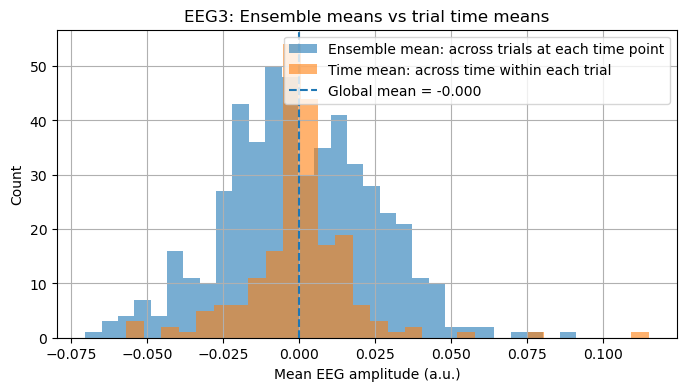

In [11]:
# ------------------------------------------------------------
# 3. Plot ensemble mean distribution vs trial time mean distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 4))

plt.hist(
    ensemble_mean_by_time,
    bins=30,
    alpha=0.6,
    label="Ensemble mean: across trials at each time point"
)

plt.hist(
    time_mean_by_trial,
    bins=30,
    alpha=0.6,
    label="Time mean: across time within each trial"
)

# Add the global mean as a vertical reference line.
plt.axvline(
    global_mean,
    linestyle="--",
    label=f"Global mean = {global_mean:.3f}"
)

plt.xlabel("Mean EEG amplitude (a.u.)")
plt.ylabel("Count")
plt.title("EEG3: Ensemble means vs trial time means")
plt.legend()
plt.grid(True)
plt.show()

### How to interpret this plot

The histogram of **ensemble means** shows how the average across trials changes over time.

The histogram of **trial time means** shows how the average of each trial changes across trials.

If both histograms are centered near the same value, then the average across time within trials and the average across trials at time points are giving similar estimates of the signal's mean.

If the trial time means are very spread out, then different trials have very different average amplitudes. That would be evidence against mean-ergodic-like behavior.

If the ensemble means are very spread out over time, then the average signal changes over time. That would be evidence against mean-stationary-like behavior.

## 4. Compute RMSE, MAE, signal standard deviation, and normalized mean-ergodicity error

Now we quantify the mean-ergodicity errors.

For each trial:

$$
\text{error}_i
=
\bar X_i^{\text{time}}
-
\mu_{\text{global}}
$$

Then we compute:

### RMSE

$$
\text{RMSE}
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
\text{error}_i^2
}
$$

RMSE gives the typical size of the trial time-mean error. It gives more weight to large errors.

### MAE

$$
\text{MAE}
=
\frac{1}{N}
\sum_{i=1}^{N}
|\text{error}_i|
$$

MAE gives the average absolute size of the error.

### Full signal standard deviation

$$
s_X
=
\sqrt{
\frac{1}{NT-1}
\sum_{i=1}^{N}
\sum_{t=1}^{T}
(x_{i,t}-\mu_{\text{global}})^2
}
$$

This gives the typical variability of the full EEG signal.

### Normalized mean-ergodicity error

$$
E_\mu
=
\frac{\text{RMSE}}{s_X}
$$

This tells us how large the trial time-mean errors are relative to the natural variability of the signal.

In [12]:
# ------------------------------------------------------------
# 4. Compute mean-ergodicity error metrics
# ------------------------------------------------------------

# RMSE:
# Square each trial error, average the squared errors,
# and take the square root.
rmse = np.sqrt(np.mean(mean_errors ** 2))

# MAE:
# Take the absolute value of each trial error and average them.
mae = np.mean(np.abs(mean_errors))

# Standard deviation of the full EEG signal.
# ddof=1 means sample standard deviation.
signal_std = X3.std(ddof=1)

# Normalized mean-ergodicity error.
# This expresses the RMSE relative to the full signal variability.
E_mu = rmse / signal_std


print("Global mean:", global_mean)
print("RMSE of trial time-mean errors:", rmse)
print("MAE of trial time-mean errors:", mae)
print("Standard deviation of full signal:", signal_std)
print("Normalized mean-ergodicity error E_mu:", E_mu)

Global mean: -3.7612338736453036e-05
RMSE of trial time-mean errors: 0.018037591051838452
MAE of trial time-mean errors: 0.01101825242363819
Standard deviation of full signal: 0.3535938631137443
Normalized mean-ergodicity error E_mu: 0.05101217225038804


## 5. Plot the distribution of trial time-mean errors

This plot shows the distribution of:

$$
\text{error}_i
=
\bar X_i^{\text{time}}
-
\mu_{\text{global}}
$$

Each value tells us whether one trial's time average is above or below the global mean.

### What we should look for

If the errors are tightly concentrated around zero, then trial time means are close to the global mean.

That supports mean-ergodic-like behavior.

If the errors are spread out or shifted away from zero, then different trials have very different time averages.

That suggests individual trials may not represent the global process mean well.

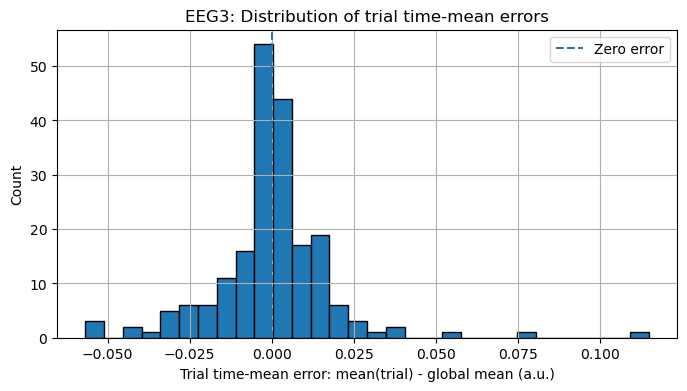

In [13]:
# ------------------------------------------------------------
# 5. Plot distribution of trial time-mean errors
# ------------------------------------------------------------

plt.figure(figsize=(8, 4))

plt.hist(
    mean_errors,
    bins=30,
    edgecolor="black"
)

# Zero error means:
# trial time mean = global mean.
plt.axvline(
    0,
    linestyle="--",
    label="Zero error"
)

plt.xlabel("Trial time-mean error: mean(trial) - global mean (a.u.)")
plt.ylabel("Count")
plt.title("EEG3: Distribution of trial time-mean errors")
plt.legend()
plt.grid(True)
plt.show()

### How to interpret this plot

The dashed vertical line represents zero error.

Values near zero mean that the trial's time mean is close to the global mean.

Values to the right of zero mean that the trial's time mean is higher than the global mean.

Values to the left of zero mean that the trial's time mean is lower than the global mean.

A narrow distribution around zero supports mean-ergodic-like behavior.

A wide distribution means that the time average depends strongly on which trial we picked.

## 6. Check convergence of cumulative trial averages

Ergodicity is theoretically about what happens when we observe one realization for a very long time.

In real finite data, we cannot observe infinite time.

So we ask a practical question:

> As we include more and more time points, do the trial averages move closer to the global mean?

For each trial, the cumulative mean at window length $w$ is:

$$
\bar X_i^{\text{time}}(w)
=
\frac{1}{w}
\sum_{t=1}^{w}
x_{i,t}
$$

Then we compare it to the global mean:

$$
\left|
\bar X_i^{\text{time}}(w)
-
\mu_{\text{global}}
\right|
$$

For each window length, we average this error across trials.

In [14]:
# ------------------------------------------------------------
# 6. Cumulative means and convergence errors
# ------------------------------------------------------------

# Cumulative sum across time for each trial.
#
# axis=1 means we move along columns/time points.
#
# Example:
# If a trial is [2, 4, 6],
# cumulative sum is [2, 6, 12].
cumulative_sums = np.cumsum(X3, axis=1)

# Create an array with window lengths:
#
# [1, 2, 3, ..., T]
#
# Dividing the cumulative sums by these window lengths gives
# the cumulative mean at each time point.
window_lengths = np.arange(1, T + 1)

cumulative_means = cumulative_sums / window_lengths

# Compute absolute error between each cumulative mean
# and the global mean.
#
# Shape:
#   same as X3, namely (N, T)
#
# Each entry tells us:
#   how far trial i's running mean at window w
#   is from the global mean.
cumulative_errors = np.abs(cumulative_means - global_mean)

# Average the cumulative error across trials for each window length.
#
# This gives one value per time window.
mean_error_by_window = cumulative_errors.mean(axis=0)


print("Shape of cumulative_means:", cumulative_means.shape)
print("Shape of cumulative_errors:", cumulative_errors.shape)
print("Shape of mean_error_by_window:", mean_error_by_window.shape)

Shape of cumulative_means: (199, 500)
Shape of cumulative_errors: (199, 500)
Shape of mean_error_by_window: (500,)


## 7. Plot convergence of cumulative trial averages

This plot shows how the mean absolute error changes as we include more time points in each trial's running average.

The x-axis is the window length.

The y-axis is the average error from the global mean across trials.

### What we should look for

If the curve decreases as window length increases, then trial time averages are moving closer to the global mean.

That supports mean-ergodic-like behavior.

If the curve stays high or increases, then adding more time points does not make the trial averages better representatives of the global mean.

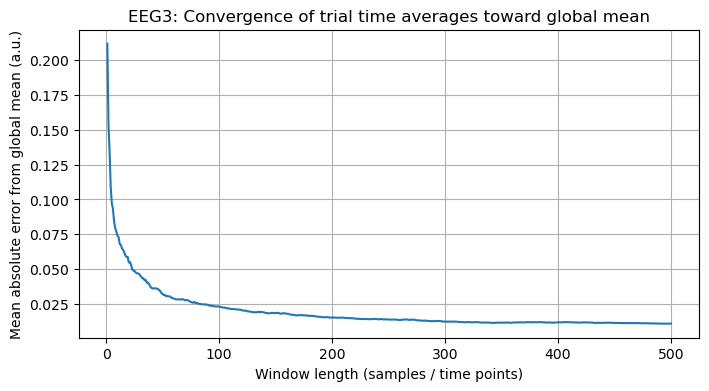

In [15]:
# ------------------------------------------------------------
# 7. Plot convergence of cumulative trial averages
# ------------------------------------------------------------

plt.figure(figsize=(8, 4))

plt.plot(
    window_lengths,
    mean_error_by_window
)

plt.xlabel("Window length (samples / time points)")
plt.ylabel("Mean absolute error from global mean (a.u.)")
plt.title("EEG3: Convergence of trial time averages toward global mean")
plt.grid(True)
plt.show()

### How to interpret this plot

Each point shows the average error from the global mean when using only the first $w$ time points of each trial.

At small window lengths, the running average can be unstable because it uses very few samples.

As the window length increases, the running average uses more of the trial.

If the signal is mean-ergodic-like, the error should generally become smaller as the window length increases.

The curve does not need to decrease perfectly at every single step, because real finite signals fluctuate.

The important question is whether the overall trend moves toward smaller error.

## 8. Define a reusable function for normalized mean-ergodicity error

Now we define a function that computes:

$$
E_\mu =
\frac{\text{RMSE of trial time-mean errors}}{s_X}
$$

This function is useful because we will use the same metric for:

1. The observed EEG3 data.
2. Many surrogate datasets.

A small value of $E_\mu$ means that trial time means are close to the global mean relative to the signal's variability.

In [16]:
# ------------------------------------------------------------
# 8. Function to compute normalized mean-ergodicity error
# ------------------------------------------------------------

def normalized_mean_error(X):
    """
    Compute the normalized mean-ergodicity error.

    Parameters
    ----------
    X : numpy.ndarray
        Data matrix with shape (n_trials, n_timepoints).
        Rows are trials and columns are time points.

    Returns
    -------
    E_mu : float
        Normalized mean-ergodicity error.

    Explanation
    -----------
    1. Compute the time mean of each trial.
    2. Compute the global mean of the full matrix.
    3. Compute the error between each trial time mean and the global mean.
    4. Compute RMSE of those errors.
    5. Normalize by the standard deviation of the full signal.

    Formula
    -------
    E_mu = RMSE(time_mean_by_trial - global_mean) / std(full signal)
    """

    # Average each trial across time.
    time_means = X.mean(axis=1)

    # Average the full matrix.
    global_mean = X.mean()

    # Difference between each trial time mean and the global mean.
    errors = time_means - global_mean

    # Typical size of the trial time-mean errors.
    rmse = np.sqrt(np.mean(errors ** 2))

    # Typical variability of the full signal.
    signal_std = X.std(ddof=1)

    # Normalize error by the signal's variability.
    E_mu = rmse / signal_std

    return E_mu

In [17]:
observed_E_mu = normalized_mean_error(X3)

print("Observed normalized mean-ergodicity error E_mu:", observed_E_mu)

Observed normalized mean-ergodicity error E_mu: 0.05101217225038804


## 9. Surrogate analysis with circularly shifted trials

Now we ask:

> Is the observed normalized mean-ergodicity error unusual?

To answer this, we generate surrogate datasets.

Each surrogate dataset is created by circularly shifting each trial by a random amount.

For example, if a trial is:

$$
[1,\ 2,\ 3,\ 4,\ 5]
$$

and the circular shift is 2, then:

$$
[1,\ 2,\ 3,\ 4,\ 5]
\rightarrow
[4,\ 5,\ 1,\ 2,\ 3]
$$

The values are not destroyed. They are only rotated.

This means each trial keeps:

- the same values,
- the same trial mean,
- the same trial variance,
- much of its internal temporal structure.

But the alignment of that trial relative to the original time axis changes.

This helps us ask:

> How large is the normalized mean error under random timing shifts?

Then we compare the observed value with the surrogate distribution.

In [18]:
# ------------------------------------------------------------
# 9. Generate surrogate datasets using circular shifts
# ------------------------------------------------------------

# Compute the observed error in the original EEG3 data.
observed_E_mu = normalized_mean_error(X3)

# Number of surrogate datasets to generate.
n_surrogates = 1000

# Store one normalized error value per surrogate dataset.
surrogate_E_mu = []

# Get the number of trials and time points.
N, T = X3.shape


for surrogate_index in range(n_surrogates):

    # Create an empty matrix with the same shape as X3.
    # We will fill it with circularly shifted trials.
    X_shifted = np.empty_like(X3)

    # Shift each trial independently.
    for trial_index in range(N):

        # Choose a random circular shift between 0 and T-1.
        random_shift = np.random.randint(0, T)

        # Circularly shift this trial.
        #
        # Example:
        # np.roll([1, 2, 3, 4, 5], 2)
        # gives [4, 5, 1, 2, 3].
        X_shifted[trial_index, :] = np.roll(
            X3[trial_index, :],
            random_shift
        )

    # Compute the normalized mean-ergodicity error
    # for this surrogate dataset.
    E_mu_shifted = normalized_mean_error(X_shifted)

    # Store it.
    surrogate_E_mu.append(E_mu_shifted)


# Convert list to NumPy array for easier analysis.
surrogate_E_mu = np.array(surrogate_E_mu)

# Compute 95th percentile of surrogate errors.
#
# This gives a data-based threshold:
# 95% of surrogate errors are below this value.
threshold_95 = np.percentile(surrogate_E_mu, 95)


print("Observed E_mu:", observed_E_mu)
print("95% surrogate threshold:", threshold_95)

if observed_E_mu <= threshold_95:
    print("Result: Compatible with surrogate ergodic-like behavior.")
else:
    print("Result: Larger discrepancy than expected under surrogate.")

Observed E_mu: 0.05101217225038804
95% surrogate threshold: 0.05101217225038805
Result: Compatible with surrogate ergodic-like behavior.


## 10. Plot surrogate distribution and observed value

The surrogate distribution shows the normalized mean-ergodicity errors obtained after randomly circularly shifting trials.

The observed value is the normalized mean-ergodicity error from the original EEG3 data.

The 95th percentile is used as a reference threshold.

### What we should look for

If the observed value is below or close to the surrogate distribution, then the observed error is not unusually large.

If the observed value is above the 95th percentile, then the observed trial time means are farther from the global mean than expected under the circular-shift surrogate.

## Important note about the circular-shift surrogate

In this analysis, the circular-shift surrogate does not create a meaningful distribution of normalized mean-ergodicity errors.

This happens because the metric:

$$
E_\mu =
\frac{
\text{RMSE}(\bar X_i^{\text{time}}-\mu_{\text{global}})
}{
s_X
}
$$

depends on the time mean of each trial.

A circular shift changes the order of values inside a trial, but it does not change the values themselves.

For example:

$$
[1,\ 2,\ 3,\ 4,\ 5]
$$

and:

$$
[4,\ 5,\ 1,\ 2,\ 3]
$$

have exactly the same mean.

Therefore, after circularly shifting each trial:

- each trial keeps the same time mean,
- the global mean stays the same,
- the full signal standard deviation stays the same,
- the normalized mean-ergodicity error stays the same.

So the surrogate values collapse to almost one identical number.

This means the circular-shift surrogate is not useful for testing this specific mean-ergodicity metric.

Circular shifts are more useful for metrics that depend on temporal alignment or temporal structure, such as:

- autocorrelation,
- covariance structure,
- phase alignment,
- event-locked responses,
- time-dependent ensemble means.

For the normalized mean-ergodicity error, a better surrogate would need to change how values are assigned to trials, not only rotate values within each trial.

Surrogate min: 0.051012172250388024
Surrogate max: 0.051012172250388066
Surrogate range: 4.163336342344337e-17


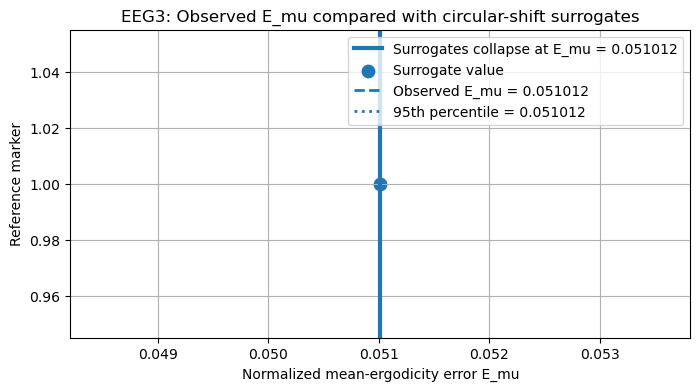

In [19]:
# ------------------------------------------------------------
# 10. Plot surrogate result robustly
# ------------------------------------------------------------

plt.figure(figsize=(8, 4))

# Remove possible NaN or infinite values
surrogate_E_mu_clean = surrogate_E_mu[np.isfinite(surrogate_E_mu)]

# Compute range of surrogate values
surrogate_min = np.min(surrogate_E_mu_clean)
surrogate_max = np.max(surrogate_E_mu_clean)
surrogate_range = surrogate_max - surrogate_min

print("Surrogate min:", surrogate_min)
print("Surrogate max:", surrogate_max)
print("Surrogate range:", surrogate_range)

# Because circular shifting preserves trial means,
# surrogate_E_mu may have almost zero variation.
if np.isclose(surrogate_min, surrogate_max):
    common_surrogate_value = np.mean(surrogate_E_mu_clean)

    plt.axvline(
        common_surrogate_value,
        linewidth=3,
        label=f"Surrogates collapse at E_mu = {common_surrogate_value:.6f}"
    )

    plt.scatter(
        [common_surrogate_value],
        [1],
        s=80,
        label="Surrogate value"
    )

    plt.ylabel("Reference marker")
else:
    plt.hist(
        surrogate_E_mu_clean,
        bins=30,
        edgecolor="black",
        alpha=0.7,
        label="Surrogate E_mu values"
    )

    plt.ylabel("Count")

plt.axvline(
    observed_E_mu,
    linestyle="--",
    linewidth=2,
    label=f"Observed E_mu = {observed_E_mu:.6f}"
)

plt.axvline(
    threshold_95,
    linestyle=":",
    linewidth=2,
    label=f"95th percentile = {threshold_95:.6f}"
)

plt.xlabel("Normalized mean-ergodicity error E_mu")
plt.title("EEG3: Observed E_mu compared with circular-shift surrogates")
plt.legend()
plt.grid(True)
plt.show()

### How to interpret this plot

The histogram shows the surrogate values of $E_\mu$.

The dashed vertical line shows the observed $E_\mu$ from the real EEG3 data.

The dotted vertical line shows the 95th percentile of the surrogate distribution.

If the observed line is to the left of the 95th percentile, then the observed error is not unusually large compared with the surrogate datasets.

If the observed line is to the right of the 95th percentile, then the observed error is larger than expected under the circular-shift surrogate procedure.

This does not prove or disprove true theoretical ergodicity.

It is a finite-data diagnostic that helps us ask whether the observed trial time means are unusually inconsistent relative to a reference distribution created from the data itself.

## Artificial comparison: when a surrogate distribution collapses vs when it becomes meaningful

In the EEG3 circular-shift surrogate, the surrogate distribution collapsed to almost one value.

This happened because circularly shifting each trial preserves:

- each trial's time mean,
- the global mean,
- the full signal standard deviation,
- and therefore the normalized mean-ergodicity error $E_\mu$.

So the surrogate values did not form a meaningful distribution.

To understand what a meaningful surrogate distribution should look like, we can create artificial data and compare two surrogate strategies:

1. **Circular-shift surrogate**  
   This rotates values inside each trial.  
   It preserves each trial's mean, so $E_\mu$ does not change.

2. **Trial-value reshuffling surrogate**  
   This redistributes values across trials.  
   It changes the time mean of each trial, so $E_\mu$ changes across surrogate datasets.

The second surrogate produces a real distribution and is useful for illustrating what we expected to see conceptually.

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Define the normalized mean-ergodicity error function
# ------------------------------------------------------------
# This is the same metric used before:
#
# E_mu = RMSE(trial time means - global mean) / std(full signal)
#
# It asks:
# How far are trial time means from the global mean,
# relative to the full signal variability?

def normalized_mean_error(X):
    """
    Compute normalized mean-ergodicity error.

    Parameters
    ----------
    X : numpy.ndarray
        Data matrix with shape (n_trials, n_timepoints).

    Returns
    -------
    E_mu : float
        Normalized mean-ergodicity error.
    """

    time_means = X.mean(axis=1)
    global_mean = X.mean()
    errors = time_means - global_mean
    rmse = np.sqrt(np.mean(errors ** 2))
    signal_std = X.std(ddof=1)

    return rmse / signal_std

## 1. Create artificial EEG-like data

We create a small synthetic dataset with several trials and time points.

The data are designed to have:

- random fluctuations,
- slightly different trial baselines,
- enough variability to make the example realistic.

This is not meant to perfectly simulate EEG. It is only a teaching example to show how surrogate distributions behave.

In [21]:
# ------------------------------------------------------------
# 2. Create artificial EEG-like data
# ------------------------------------------------------------

np.random.seed(42)

N = 80      # number of trials
T = 300     # number of time points

# Base random signal
# This represents trial-by-time EEG-like fluctuations.
noise = np.random.normal(loc=0, scale=1, size=(N, T))

# Add small trial-specific baseline shifts.
# Some trials are slightly higher or lower on average.
trial_offsets = np.random.normal(loc=0, scale=0.25, size=(N, 1))

# Add a weak slow oscillatory component shared across trials.
time = np.linspace(0, 2 * np.pi, T)
slow_component = 0.4 * np.sin(time)

# Artificial EEG-like data matrix
X_artificial = noise + trial_offsets + slow_component

# Compute observed E_mu
observed_E_artificial = normalized_mean_error(X_artificial)

print("Artificial data shape:", X_artificial.shape)
print("Observed E_mu for artificial data:", observed_E_artificial)

Artificial data shape: (80, 300)
Observed E_mu for artificial data: 0.23500092231752237


## 2. Circular-shift surrogate

First, we use the same surrogate strategy as before: circularly shifting each trial.

This should collapse the surrogate distribution because circular shifting does not change the time mean of each trial.

For example:

$$
[1,\ 2,\ 3,\ 4,\ 5]
$$

and:

$$
[4,\ 5,\ 1,\ 2,\ 3]
$$

have the same mean.

Therefore, $E_\mu$ should remain almost exactly the same across all circular-shift surrogates.

In [22]:
# ------------------------------------------------------------
# 3. Circular-shift surrogate
# ------------------------------------------------------------

n_surrogates = 1000
surrogate_E_circular = []

for surrogate_index in range(n_surrogates):

    X_shifted = np.empty_like(X_artificial)

    for trial_index in range(N):
        random_shift = np.random.randint(0, T)
        X_shifted[trial_index, :] = np.roll(
            X_artificial[trial_index, :],
            random_shift
        )

    E_shifted = normalized_mean_error(X_shifted)
    surrogate_E_circular.append(E_shifted)

surrogate_E_circular = np.array(surrogate_E_circular)

print("Circular-shift surrogate:")
print("min:", surrogate_E_circular.min())
print("max:", surrogate_E_circular.max())
print("range:", surrogate_E_circular.max() - surrogate_E_circular.min())
print("observed E_mu:", observed_E_artificial)

Circular-shift surrogate:
min: 0.23500092231752237
max: 0.23500092231752237
range: 0.0
observed E_mu: 0.23500092231752237


## 3. Value-reshuffling surrogate across the full matrix

Now we create a surrogate that actually changes trial time means.

We flatten the full matrix into one long vector, shuffle all values, and then reshape it back into the original matrix shape.

This keeps the global distribution of amplitudes the same, but it changes which values appear in each trial.

Therefore:

- the global mean stays approximately the same,
- the full signal standard deviation stays approximately the same,
- but the time mean of each trial can change.

So $E_\mu$ changes across surrogate datasets.

This creates a real surrogate distribution.

In [23]:
# ------------------------------------------------------------
# 4. Full value-reshuffling surrogate
# ------------------------------------------------------------
# This surrogate changes which values belong to which trial.
#
# It preserves the full set of values in the dataset,
# but redistributes them across the matrix.

surrogate_E_shuffle = []

flat_values = X_artificial.flatten()

for surrogate_index in range(n_surrogates):

    # Randomly permute all values from the full matrix
    shuffled_values = np.random.permutation(flat_values)

    # Reshape back into trial-by-time matrix
    X_shuffled = shuffled_values.reshape(N, T)

    # Compute normalized mean-ergodicity error
    E_shuffled = normalized_mean_error(X_shuffled)

    surrogate_E_shuffle.append(E_shuffled)

surrogate_E_shuffle = np.array(surrogate_E_shuffle)

threshold_95_shuffle = np.percentile(surrogate_E_shuffle, 95)

print("Value-reshuffling surrogate:")
print("min:", surrogate_E_shuffle.min())
print("max:", surrogate_E_shuffle.max())
print("range:", surrogate_E_shuffle.max() - surrogate_E_shuffle.min())
print("95th percentile:", threshold_95_shuffle)
print("observed E_mu:", observed_E_artificial)

Value-reshuffling surrogate:
min: 0.040451059393538734
max: 0.07173297838748234
range: 0.03128191899394361
95th percentile: 0.06464013747069913
observed E_mu: 0.23500092231752237


## 4. Plot comparison of both surrogate strategies

Now we compare both surrogate strategies visually.

The left plot shows the circular-shift surrogate.

The right plot shows the value-reshuffling surrogate.

The important difference is:

- circular shift produces almost no spread,
- value reshuffling produces a real distribution.

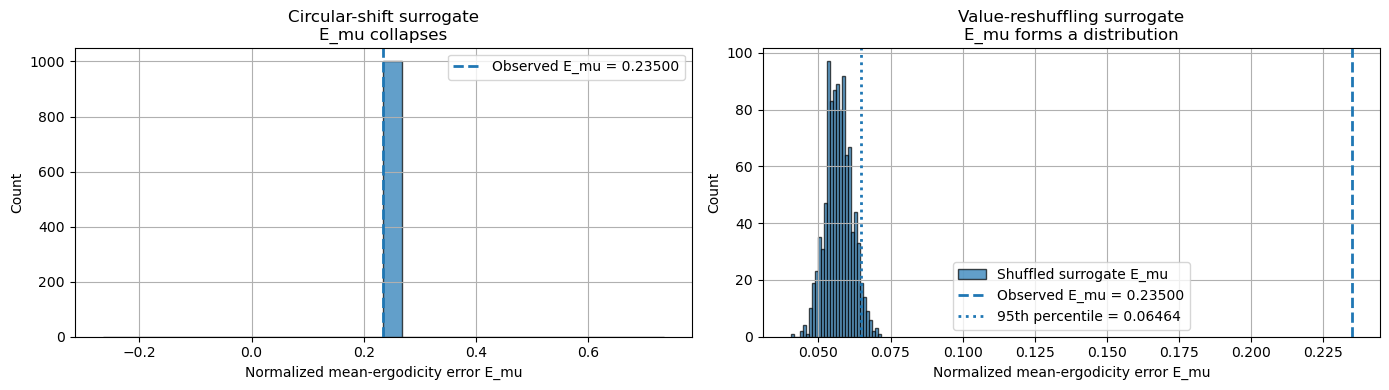

In [24]:
# ------------------------------------------------------------
# 5. Plot comparison
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ------------------------------------------------------------
# Left plot: circular-shift surrogate
# ------------------------------------------------------------

axes[0].hist(
    surrogate_E_circular,
    bins=30,
    edgecolor="black",
    alpha=0.7
)

axes[0].axvline(
    observed_E_artificial,
    linestyle="--",
    linewidth=2,
    label=f"Observed E_mu = {observed_E_artificial:.5f}"
)

axes[0].set_title("Circular-shift surrogate\nE_mu collapses")
axes[0].set_xlabel("Normalized mean-ergodicity error E_mu")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(True)


# ------------------------------------------------------------
# Right plot: value-reshuffling surrogate
# ------------------------------------------------------------

axes[1].hist(
    surrogate_E_shuffle,
    bins=30,
    edgecolor="black",
    alpha=0.7,
    label="Shuffled surrogate E_mu"
)

axes[1].axvline(
    observed_E_artificial,
    linestyle="--",
    linewidth=2,
    label=f"Observed E_mu = {observed_E_artificial:.5f}"
)

axes[1].axvline(
    threshold_95_shuffle,
    linestyle=":",
    linewidth=2,
    label=f"95th percentile = {threshold_95_shuffle:.5f}"
)

axes[1].set_title("Value-reshuffling surrogate\nE_mu forms a distribution")
axes[1].set_xlabel("Normalized mean-ergodicity error E_mu")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## How to interpret the comparison

### Circular-shift surrogate

In the circular-shift surrogate, each trial is rotated in time.

This changes the temporal alignment of the signal, but it does not change the values inside each trial.

Because the time mean of each trial is unchanged, the normalized mean-ergodicity error $E_\mu$ is also unchanged.

Therefore, the surrogate values collapse to almost one number.

This is what happened with EEG3.

So the circular-shift surrogate is not useful for testing this specific metric.

---

### Value-reshuffling surrogate

In the value-reshuffling surrogate, the full set of signal values is preserved, but the values are reassigned across trials and time points.

This changes the time mean of each trial.

Therefore, $E_\mu$ changes across surrogate datasets.

This produces a real surrogate distribution.

This is closer to what we expected visually when thinking about a surrogate test.

---

## Main lesson

A surrogate method must change the property that your metric depends on.

The metric:

$$
E_\mu =
\frac{
\text{RMSE}(\bar X_i^{\text{time}}-\mu_{\text{global}})
}{
s_X
}
$$

depends mainly on trial time means.

So a surrogate that preserves trial time means, such as circular shifting, will not create a meaningful null distribution for this metric.

A surrogate that changes trial time means, such as reshuffling values across the full matrix, will create a meaningful distribution.

However, the choice of surrogate should always match the scientific question.

Circular shifts are useful for temporal-structure questions.

Full value reshuffling is useful here as a teaching example, but it destroys temporal structure, so it should be interpreted carefully.

## 11. Final interpretation of the EEG3 analysis

This analysis checks whether EEG3 shows mean-ergodic-like behavior.

The main quantities are:

- the trial time means,
- the global mean,
- the trial time-mean errors,
- RMSE,
- MAE,
- normalized mean-ergodicity error,
- convergence of cumulative trial averages,
- surrogate comparison using circular shifts.

If the trial time means are close to the global mean, then individual trials are reasonable representatives of the full dataset mean.

If the normalized error $E_\mu$ is small, then the trial time-mean errors are small relative to the natural variability of the signal.

If cumulative errors decrease with window length, then using more time points improves the estimate of the global mean.

If the observed $E_\mu$ is not larger than the surrogate threshold, then the observed mean-ergodicity error is compatible with what we would expect under the circular-shift surrogate.

Together, these results provide evidence for or against **mean-ergodic-like behavior** in the EEG3 dataset.

However, this analysis does not prove true mathematical ergodicity, because true ergodicity is a theoretical property involving infinitely long observations. With finite EEG data, we can only evaluate whether the data behave in an ergodic-like way according to the diagnostics we computed.